### 1. Importing the libraries
numpy, matplotlib.pyplot, seaborn: For numerical operations, plotting graphs, and visualizations.
#sklearn.metrics: For generating classification reports and confusion matrices.
#tensorflow.keras: For building and training the convolutional neural network (CNN).
#os: For interacting with the operating system to handle file paths.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.preprocessing import image
import os

### 2. Data Prepration with Image Data Generator
Dataset Path: train_data_dir specifies the path to the dataset directory containing images categorized into 'benign' and 'malignant' subfolders.
Data Augmentation: train_datagen is an ImageDataGenerator object that performs real-time data augmentation and  normalization on the images during training. This includes rescaling pixel values to the range [0, 1], applying shear transformations, zooming, and horizontal flipping. validation_split=0.2 reserves 20% of the data for validation.

In [2]:

# Specify path to your dataset
train_data_dir = r'C:\Users\rizwa\Desktop\Minor Project\dataset'

In [3]:

# Data augmentation and normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

### 3.Data Flow
Data Generators: train_generator and validation_generator are iterators that yield batches of augmented images and their labels during training and validation phases. They fetch images from train_data_dir, resize them to (150, 150), batch size of 32, and categorize them into binary classes ('benign' and 'malignant'). subset='training' and subset='validation' specify whether the generator is for training or validation data.

In [4]:

# Generate batches of augmented data
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    classes=['normal', 'benign', 'malignant'],
    seed=42)

validation_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    classes=['normal', 'benign', 'malignant'],
    seed=42)

Found 2026 images belonging to 3 classes.
Found 505 images belonging to 3 classes.


### 4.Building the CNN Model
CNN Architecture: model is initialized as a Sequential model.
Convolutional Layers: Three sets of convolutional (Conv2D) and max-pooling (MaxPooling2D) layers are added sequentially, with increasing depth (32, 64, and 128 filters respectively).
Flatten and Dense Layers: After convolutional layers, a Flatten layer reshapes the output into a 1D vector. Followed by two fully connected (Dense) layers: one with 128 neurons and ReLU activation, and another output layer with a single neuron and sigmoid activation for binary classification.

In [5]:

# Initialize the CNN
model = Sequential()

# Convolutional layers
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(3, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\rizwa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

### 5.Training the model
Model Training: model.fit trains the CNN on train_generator data for 20 epochs. steps_per_epoch and validation_steps are calculated based on batch size to iterate through training and validation data respectively.

In [6]:

history = model.fit(
    train_generator,
    steps_per_epoch=1000 // 32,  # 100 images / batch size
    epochs=20,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // 32)

Epoch 1/20


C:\Users\rizwa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 544ms/step - accuracy: 0.4247 - loss: 1.2497 - val_accuracy: 0.6187 - val_loss: 0.8611
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 363ms/step - accuracy: 0.5869 - loss: 0.8697 - val_accuracy: 0.2400 - val_loss: 1.0028
Epoch 3/20


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.6089 - loss: 0.7181 - val_accuracy: 0.6458 - val_loss: 0.7153
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 396ms/step - accuracy: 0.6561 - loss: 0.7679 - val_accuracy: 0.3600 - val_loss: 0.9014
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 484ms/step - accuracy: 0.6248 - loss: 0.7403 - val_accuracy: 0.6687 - val_loss: 0.6721
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5605 - loss: 0.7570 - val_accuracy: 0.2800 - val_loss: 1.0456
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 507ms/step - accuracy: 0.6456 - loss: 0.6974 - val_accuracy: 0.6417 - val_loss: 0.6733
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 372ms/step - accuracy: 0.6818 - loss: 0.6502 - val_accuracy: 0.2800 - val_loss: 1.1515
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.7823 - loss: 0.4783 - val_accuracy: 0.7042 - val_loss: 0.6573
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 383ms/step - accuracy: 0.7193 - loss: 0.6279 - val_accuracy: 0.1600 -

### 6. Model Accuracy and Loss
Training History Visualization: Plots training and validation accuracy ('accuracy') and loss ('loss') metrics over epochs using matplotlib.

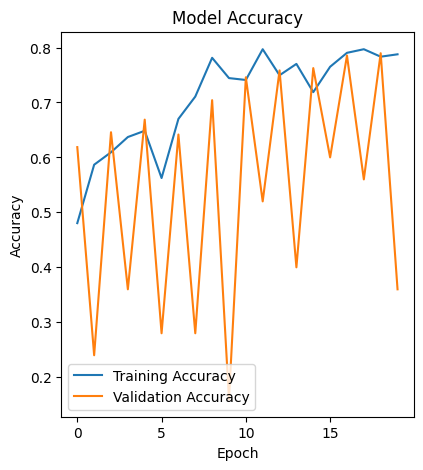

In [7]:

# Plot training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

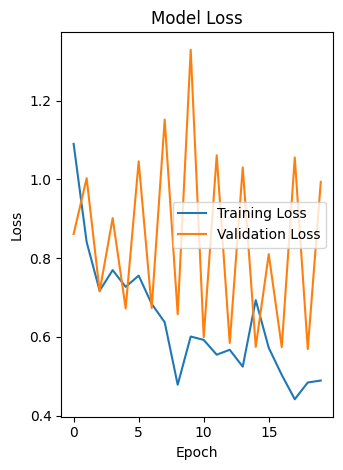

In [8]:

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

### 7.Prediction Function
Taking input of images and predicting analysisc of it

In [9]:

def predict_image_class(model, img_path):
    try:
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"File not found at {img_path}")

        img = image.load_img(img_path, target_size=(150, 150))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0

        predictions = model.predict(img_array)
        class_idx = np.argmax(predictions[0])

        class_labels = ['normal', 'benign', 'malignant']
        return class_labels[class_idx]
    
    except Exception as e:
        print(f"Error loading/predicting image: {e}")
        return None

### 8.Testing and Visualization

predict_image_class function loads and preprocesses a single image (img_path), resizes it to (150, 150), normalizes pixel values, and predicts the class probability using model.predict.
User inputs the path to an image and predict_image_class function predicts if the image is 'Benign' or 'Malignant'.
If successful, it prints the predicted class and evaluates the model's accuracy on the test set (test_generator).
It also displays a confusion matrix, classification report, and saves the trained model (breast_cancer_classification_model.h5).



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predicted class: benign
Found 2531 images belonging to 3 classes.
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 231ms/step - accuracy: 0.8584 - loss: 0.4091
Test accuracy: 0.8273409605026245
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 230ms/step


Confusion Matrix
[[731  34  33]
 [ 74 724  93]
 [ 55 154 633]]
Classification Report
              precision    recall  f1-score   support

      normal       0.85      0.92      0.88       798
      benign       0.79      0.81      0.80       891
   malignant       0.83      0.75      0.79       842

    accuracy                           0.82      2531
   macro avg       0.83      0.83      0.83      2531
weighted avg       0.82      0.82      0.82      2531



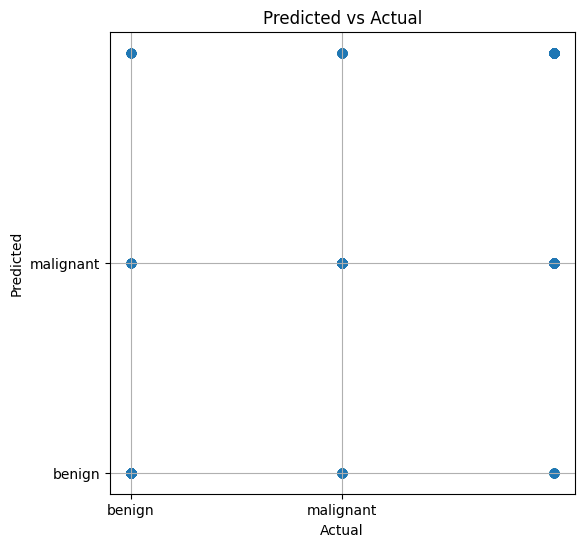

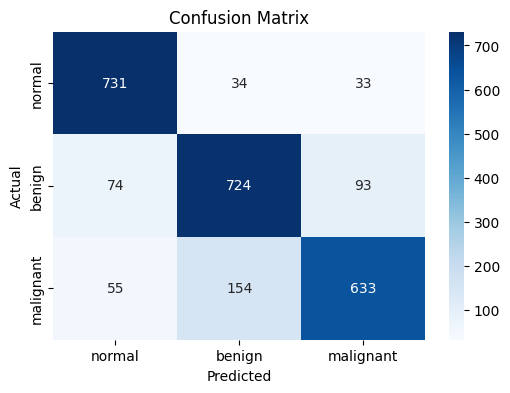

In [10]:

# Prompt user for image path
new_image_path = input("Enter the path to the image you want to classify: ").strip()

if new_image_path:
    predicted_class = predict_image_class(model, new_image_path)

    if predicted_class:
        print("Predicted class:", predicted_class)

        # Evaluate the model on test set
        test_generator = train_datagen.flow_from_directory(
            train_data_dir,
            target_size=(150, 150),
            batch_size=32,
            class_mode='categorical',
            shuffle=False,
            classes=['normal', 'benign', 'malignant'],
            seed=42)

        test_loss, test_acc = model.evaluate(test_generator)
        print('Test accuracy:', test_acc)

        # Confusion matrix and classification report
        predictions = model.predict(test_generator)
        y_pred = np.argmax(predictions,axis=1)
        y_true = test_generator.classes
        target_names = ['normal', 'benign', 'malignant']
        print('Confusion Matrix')
        print(confusion_matrix(y_true, y_pred))
        print('Classification Report')
        print(classification_report(y_true, y_pred, target_names=target_names))

        # Saving the model
        model.save('breast_cancer_classification_model.h5')

        # Dotted graph (Scatter plot)
        plt.figure(figsize=(6, 6))
        plt.scatter(test_generator.classes, y_pred, alpha=0.5)
        plt.title('Predicted vs Actual')
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.xticks([0, 1], ['benign', 'malignant'])
        plt.yticks([0, 1], ['benign', 'malignant'])
        plt.grid(True)
        plt.show()

        # Heatmap for Confusion Matrix
        conf_mat = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(conf_mat, annot=True, cmap='Blues', fmt='d', xticklabels=target_names, yticklabels=target_names)
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()
    else:
        print("Failed to predict class. Please check the path to the image.")
else:
    print("No image path provided.")

In [11]:
model.save("cnn_model.h5")